# Data Sience Project: LSTM to predict the movement of stocks

## GPU Test

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available via tf.config:", tf.config.list_physical_devices('GPU'))

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

2025-06-23 08:37:36.042013: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 08:37:36.056859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 08:37:36.074910: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 08:37:36.080389: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 08:37:36.093260: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.17.0
Built with CUDA: True
GPU available via tf.config: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16150241404785552781
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 32646561792
locality {
  bus_id: 1
  links {
  }
}
incarnation: 422206334951780125
physical_device_desc: "device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:5e:00.0, compute capability: 7.0"
xla_global_id: 416903419
]


2025-06-23 08:37:37.794858: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:5e:00.0, compute capability: 7.0


### ML Script

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import datetime as dt

import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import tensorflow as tf
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5

df = pd.read_csv('PLTR.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calculate EMA (Exponential Moving Averages)
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()

# Calculate MACD and Signal line
df['MACD'] = df['EMA12'] - df['EMA26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Calculate MACD Histogram
df['MACD_his'] = df['MACD'] - df['MACD_signal']

# Remove any rows with NaN after EMA/MACD calculations
df.dropna(inplace=True)
df = df.reset_index(drop=True)

# Then continue with your feature scaling and so on...


# === Feature selection ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# === Create supervised samples ===
X, y = [], []

for i in range(len(scaled_data) - time_steps - forward_days):
    X.append(scaled_data[i:i+time_steps])
    
    current_price = df['Close'].iloc[i+time_steps-1]
    future_price = df['Close'].iloc[i+time_steps+forward_days-1]
    pct_change = (future_price - current_price) / current_price * 100
    
    if pct_change <= -2:
        label = 0  # Big drop
    elif -2 < pct_change <= -0.5:
        label = 1  # Small drop
    elif -0.5 < pct_change < 0.5:
        label = 2  # Neutral
    elif 0.5 <= pct_change < 2:
        label = 3  # Small rise
    else:
        label = 4  # Big rise
        
    y.append(label)

X, y = np.array(X), np.array(y)

# === Optional: Apply BorderlineSMOTE ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Model definition ===
def Create_LSTM_Model(units=128, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Training ===
model = Create_LSTM_Model()
history = model.fit(X_train, y_train, epochs=1000, batch_size=1022, validation_data=(X_test, y_test))

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)


from collections import Counter

counts_origin = Counter(y_test)
unique_labels = np.unique(y_test)

print("Per-class accuracy:")
for i in unique_labels:
    if i < conf_mat.shape[0] and i < conf_mat.shape[1]:
        correct = conf_mat[i, i]
        total = sum(conf_mat[i, :])  # total true samples of class i
        acc = 100 * correct / total if total > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")
    else:
        print(f"Label {i} not present in confusion matrix")

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)


# === Manually inspect one test sample ===

# REBUILD the index map used when creating X and y
X_indices = []
for i in range(len(scaled_data) - time_steps - forward_days):
    X_indices.append(i)
X_indices = np.array(X_indices)

# Re-split the indices just like the features
_, X_test_indices = train_test_split(X_indices, test_size=0.1, random_state=42)

# Choose a test sample index to inspect (between 0 and len(X_test)-1)
test_sample_idx = 5  # Change this number as desired

# Get original index in the full df for this test sample
original_df_index = X_test_indices[test_sample_idx]

# Display relevant info
print("\n=== Manual Prediction Inspection ===")
print(f"Sample index in df: {original_df_index}")
print("Current date:", df.iloc[original_df_index + time_steps - 1]['Date'])
print("Future date:", df.iloc[original_df_index + time_steps + forward_days - 1]['Date'])
print("Current price:", df.iloc[original_df_index + time_steps - 1]['Close'])
print("Future price:", df.iloc[original_df_index + time_steps + forward_days - 1]['Close'])
print(f"Actual % change: {((df.iloc[original_df_index + time_steps + forward_days - 1]['Close'] - df.iloc[original_df_index + time_steps - 1]['Close']) / df.iloc[original_df_index + time_steps - 1]['Close']) * 100:.2f}%")
print(f"True label: {y_test[test_sample_idx]} (actual movement class)")
print(f"Predicted label: {y_pred[test_sample_idx]}")


Num GPUs Available: 1



KeyboardInterrupt



In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 6
classes = 5
max_samples = 30  # Maximum number of random samples to include in Excel

# === Load data ===
df = pd.read_csv('GOOGL.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# === Calculate indicators ===
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_his'] = df['MACD'] - df['MACD_signal']

df.dropna(inplace=True)
df = df.reset_index(drop=True)

# === Feature selection ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

# Make sure these columns exist or calculate them beforehand.
# For now, let's check and create missing columns with zeros to avoid errors:
for feat in features:
    if feat not in df.columns:
        df[feat] = 0.0

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# === Create supervised samples ===
X, y = [], []
for i in range(len(scaled_data) - time_steps - forward_days):
    X.append(scaled_data[i:i+time_steps])
    
    current_price = df['Close'].iloc[i+time_steps-1]
    future_price = df['Close'].iloc[i+time_steps+forward_days-1]
    pct_change = (future_price - current_price) / current_price * 100
    
    if pct_change <= -2:
        label = 0  # Big drop
    elif -2 < pct_change <= -0.5:
        label = 1  # Small drop
    elif -0.5 < pct_change < 0.5:
        label = 2  # Neutral
    elif 0.5 <= pct_change < 2:
        label = 3  # Small rise
    else:
        label = 4  # Big rise
        
    y.append(label)

X, y = np.array(X), np.array(y)

# === Apply BorderlineSMOTE ONLY on X and y ===
X_flat = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_flat, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)

# === Define model ===
def Create_LSTM_Model(units=1000, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Train model ===
model = Create_LSTM_Model()

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=300, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=1000, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stop])

# === Evaluate model ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

from collections import Counter
counts_origin = Counter(y_test)
unique_labels = np.unique(y_test)

print("Per-class accuracy:")
for i in unique_labels:
    if i < conf_mat.shape[0] and i < conf_mat.shape[1]:
        correct = conf_mat[i, i]
        total = sum(conf_mat[i, :])
        acc = 100 * correct / total if total > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")
    else:
        print(f"Label {i} not present in confusion matrix")

# === Map test samples back to original indices where possible ===
X_flat_original = X.reshape(X.shape[0], -1)

idx_test = []
for test_sample in X_test.reshape(X_test.shape[0], -1):
    matches = np.where((X_flat_original == test_sample).all(axis=1))[0]
    if len(matches) > 0:
        idx_test.append(matches[0])
    else:
        idx_test.append(-1)  # synthetic sample

idx_test = np.array(idx_test)

# === Randomly select indices for comparison ===
np.random.seed()  # Ensure randomness each run
non_synthetic_indices = np.where(idx_test != -1)[0]
random_indices = np.random.choice(non_synthetic_indices, size=min(max_samples, len(non_synthetic_indices)), replace=False)

# === Create a DataFrame with predictions and actual values for random dates ===
results = []
for i in random_indices:
    original_idx = idx_test[i]
    current_price = df.iloc[original_idx + time_steps - 1]['Close']
    future_price = df.iloc[original_idx + time_steps + forward_days - 1]['Close']
    actual_pct_change = (future_price - current_price) / current_price * 100
    predicted_label = y_pred[i]
    true_label = y_test[i]

    results.append({
        'Current_Date': df.iloc[original_idx + time_steps - 1]['Date'],
        'Future_Date': df.iloc[original_idx + time_steps + forward_days - 1]['Date'],
        'Current_Price': current_price,
        'Future_Price': future_price,
        'Predicted_Label': predicted_label,
        'True_Label': true_label,
        'Actual_Pct_Change': actual_pct_change
    })

results_df = pd.DataFrame(results)

# Save to Excel
results_df.to_excel('prediction_results.xlsx', index=False)

print("\nSaved prediction results to 'prediction_results.xlsx'")

# === Manual inspection example for one random test sample (non-synthetic) ===
if len(random_indices) > 0:
    sample_i = random_indices[0]
    original_df_index = idx_test[sample_i]

    print("\n=== Manual Prediction Inspection ===")
    print(f"Sample index in df: {original_df_index}")
    print("Current date:", df.iloc[original_df_index + time_steps - 1]['Date'])
    print("Future date:", df.iloc[original_df_index + time_steps + forward_days - 1]['Date'])
    print("Current price:", df.iloc[original_df_index + time_steps - 1]['Close'])
    print("Future price:", df.iloc[original_df_index + time_steps + forward_days - 1]['Close'])
    print(f"Actual % change: {((df.iloc[original_df_index + time_steps + forward_days - 1]['Close'] - df.iloc[original_df_index + time_steps - 1]['Close']) / df.iloc[original_df_index + time_steps - 1]['Close']) * 100:.2f}%")
    print(f"True label: {y_test[sample_i]} (actual movement class)")
    print(f"Predicted label: {y_pred[sample_i]}")
else:
    print("No non-synthetic test samples found for manual inspection.")

Num GPUs Available: 1


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1781 - loss: 2.2484 - val_accuracy: 0.4286 - val_loss: 1.4217
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4658 - loss: 2.0283 - val_accuracy: 0.3469 - val_loss: 1.4282
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5479 - loss: 1.4757 - val_accuracy: 0.4286 - val_loss: 1.4480
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5479 - loss: 1.2538 - val_accuracy: 0.4694 - val_loss: 1.3631
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5822 - loss: 1.0996 - val_accuracy: 0.5918 - val_loss: 1.2869
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5822 - loss: 1.2175 - val_accuracy: 0.6122 - val_loss: 1.2542
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5959 - loss: 1.1089 - val_accuracy: 0.5510 - val_loss: 1.2703
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6301 - loss: 1.0939 - val_accuracy: 0.428

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 6
classes = 5
max_samples = 30  # Maximum number of random samples to include in Excel

# === Load data ===
df = pd.read_csv('AAPL.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# === Calculate indicators ===
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_his'] = df['MACD'] - df['MACD_signal']

df.dropna(inplace=True)
df = df.reset_index(drop=True)

# === Feature selection ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

# Make sure these columns exist or calculate them beforehand.
# For now, let's check and create missing columns with zeros to avoid errors:
for feat in features:
    if feat not in df.columns:
        df[feat] = 0.0

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# === Create supervised samples ===
X, y = [], []
for i in range(len(scaled_data) - time_steps - forward_days):
    X.append(scaled_data[i:i+time_steps])
    
    current_price = df['Close'].iloc[i+time_steps-1]
    future_price = df['Close'].iloc[i+time_steps+forward_days-1]
    pct_change = (future_price - current_price) / current_price * 100
    
    if pct_change <= -2:
        label = 0  # Big drop
    elif -2 < pct_change <= -0.5:
        label = 1  # Small drop
    elif -0.5 < pct_change < 0.5:
        label = 2  # Neutral
    elif 0.5 <= pct_change < 2:
        label = 3  # Small rise
    else:
        label = 4  # Big rise
        
    y.append(label)

X, y = np.array(X), np.array(y)

# === Apply BorderlineSMOTE ONLY on X and y ===
X_flat = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_flat, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)

# === Define model ===
def Create_LSTM_Model(units=1000, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Train model ===
model = Create_LSTM_Model()

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=300, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=1000, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stop])

# === Evaluate model ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

from collections import Counter
counts_origin = Counter(y_test)
unique_labels = np.unique(y_test)

print("Per-class accuracy:")
for i in unique_labels:
    if i < conf_mat.shape[0] and i < conf_mat.shape[1]:
        correct = conf_mat[i, i]
        total = sum(conf_mat[i, :])
        acc = 100 * correct / total if total > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")
    else:
        print(f"Label {i} not present in confusion matrix")

# === Map test samples back to original indices where possible ===
X_flat_original = X.reshape(X.shape[0], -1)

idx_test = []
for test_sample in X_test.reshape(X_test.shape[0], -1):
    matches = np.where((X_flat_original == test_sample).all(axis=1))[0]
    if len(matches) > 0:
        idx_test.append(matches[0])
    else:
        idx_test.append(-1)  # synthetic sample

idx_test = np.array(idx_test)

# === Randomly select indices for comparison ===
np.random.seed()  # Ensure randomness each run
non_synthetic_indices = np.where(idx_test != -1)[0]
random_indices = np.random.choice(non_synthetic_indices, size=min(max_samples, len(non_synthetic_indices)), replace=False)

# === Create a DataFrame with predictions and actual values for random dates ===
results = []
for i in random_indices:
    original_idx = idx_test[i]
    current_price = df.iloc[original_idx + time_steps - 1]['Close']
    future_price = df.iloc[original_idx + time_steps + forward_days - 1]['Close']
    actual_pct_change = (future_price - current_price) / current_price * 100
    predicted_label = y_pred[i]
    true_label = y_test[i]

    results.append({
        'Current_Date': df.iloc[original_idx + time_steps - 1]['Date'],
        'Future_Date': df.iloc[original_idx + time_steps + forward_days - 1]['Date'],
        'Current_Price': current_price,
        'Future_Price': future_price,
        'Predicted_Label': predicted_label,
        'True_Label': true_label,
        'Actual_Pct_Change': actual_pct_change
    })

results_df = pd.DataFrame(results)

# Save to Excel
results_df.to_excel('prediction_results_aapl.xlsx', index=False)

print("\nSaved prediction results to 'prediction_results_aapl.xlsx'")

# === Manual inspection example for one random test sample (non-synthetic) ===
if len(random_indices) > 0:
    sample_i = random_indices[0]
    original_df_index = idx_test[sample_i]

    print("\n=== Manual Prediction Inspection ===")
    print(f"Sample index in df: {original_df_index}")
    print("Current date:", df.iloc[original_df_index + time_steps - 1]['Date'])
    print("Future date:", df.iloc[original_df_index + time_steps + forward_days - 1]['Date'])
    print("Current price:", df.iloc[original_df_index + time_steps - 1]['Close'])
    print("Future price:", df.iloc[original_df_index + time_steps + forward_days - 1]['Close'])
    print(f"Actual % change: {((df.iloc[original_df_index + time_steps + forward_days - 1]['Close'] - df.iloc[original_df_index + time_steps - 1]['Close']) / df.iloc[original_df_index + time_steps - 1]['Close']) * 100:.2f}%")
    print(f"True label: {y_test[sample_i]} (actual movement class)")
    print(f"Predicted label: {y_pred[sample_i]}")
else:
    print("No non-synthetic test samples found for manual inspection.")

Num GPUs Available: 1


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1917 - loss: 2.4294 - val_accuracy: 0.4000 - val_loss: 1.4299
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4000 - loss: 2.4488 - val_accuracy: 0.4250 - val_loss: 1.4410
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3917 - loss: 2.1056 - val_accuracy: 0.5250 - val_loss: 1.3525
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.4250 - loss: 1.6167 - val_accuracy: 0.4500 - val_loss: 1.3414
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4083 - loss: 1.7414 - val_accuracy: 0.4750 - val_loss: 1.3683
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4667 - loss: 1.4579 - val_accuracy: 0.5750 - val_loss: 1.3654
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4333 - loss: 1.3976 - val_accuracy: 0.6000 - val_loss: 1.3045
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5083 - loss: 1.3283 - val_accuracy: 0.600

## Combined script all stocks

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from collections import Counter
import tensorflow as tf

# GPU memory handling
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5
folder_path = "stocks"  # Pfad zum Ordner mit CSVs

# === Features ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

X_all, y_all = [], []

# === Hilfsfunktion: Feature-Engineering ===
def process_stock(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_his'] = df['MACD'] - df['MACD_signal']
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Füge Dummy-Spalten hinzu, wenn du sie brauchst
    for f in features:
        if f not in df.columns:
            df[f] = 0.0

    # Skaliere nur die Features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    X, y = [], []
    for i in range(len(scaled) - time_steps - forward_days):
        X.append(scaled[i:i+time_steps])
        curr = df['Close'].iloc[i+time_steps-1]
        future = df['Close'].iloc[i+time_steps+forward_days-1]
        pct = (future - curr) / curr * 100
        if pct <= -2:
            label = 0
        elif -2 < pct <= -0.5:
            label = 1
        elif -0.5 < pct < 0.5:
            label = 2
        elif 0.5 <= pct < 2:
            label = 3
        else:
            label = 4
        y.append(label)

    return np.array(X), np.array(y)

# === Alle Dateien im Ordner verarbeiten ===
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        try:
            df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
            X_part, y_part = process_stock(df)
            if len(X_part) > 0:
                X_all.append(X_part)
                y_all.append(y_part)
                print(f"{file}: {len(X_part)} samples")
        except Exception as e:
            print(f"Fehler bei Datei {file}: {e}")

# === Kombinieren ===
X = np.vstack(X_all)
y = np.hstack(y_all)

# === Resampling ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Modell ===
def Create_LSTM_Model(units=128, drop_out=0.5, lr=5e-4):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === Training ===
model = Create_LSTM_Model()
history = model.fit(X_train, y_train, epochs=400, batch_size=256, validation_data=(X_test, y_test))

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

print("Per-class accuracy:")
for i in np.unique(y_test):
    if i < conf_mat.shape[0]:
        acc = 100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")






2025-06-23 08:39:29.514894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 08:39:29.529676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 08:39:29.548511: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 08:39:29.554537: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 08:39:29.569004: I tensorflow/core/platform/cpu_feature_guar

Num GPUs Available: 1
NVDA.csv: 104 samples
META.csv: 104 samples
AMZN.csv: 104 samples
HOOD.csv: 104 samples
TSLA.csv: 104 samples
GOOGL.csv: 104 samples
PLTR.csv: 104 samples
AAPL.csv: 104 samples
UBER.csv: 104 samples
GC=F.csv: 104 samples
BTC-USD.csv: 194 samples
MSFT.csv: 104 samples


2025-06-23 08:39:31.528944: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:198] Using CUDA malloc Async allocator for GPU: 0
2025-06-23 08:39:31.529323: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:5e:00.0, compute capability: 7.0
/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/400


2025-06-23 08:39:35.429368: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.2218 - loss: 2.1812 - val_accuracy: 0.2800 - val_loss: 1.5866
Epoch 2/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2449 - loss: 1.9777 - val_accuracy: 0.2655 - val_loss: 1.5850
Epoch 3/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2572 - loss: 1.9505 - val_accuracy: 0.2582 - val_loss: 1.5761
Epoch 4/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2725 - loss: 1.8259 - val_accuracy: 0.3091 - val_loss: 1.5656
Epoch 5/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2635 - loss: 1.8638 - val_accuracy: 0.3236 - val_loss: 1.5548
Epoch 6/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2819 - loss: 1.7753 - val_accuracy: 0.3455 - val_loss: 1.5427
Epoch 7/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3155 - loss: 1.7249 - val_accuracy: 0.3382 - val_loss: 1.5330
Epoch 8/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2937 - loss: 1.7509 - val_accuracy: 0.3782 - val_l

## Plots

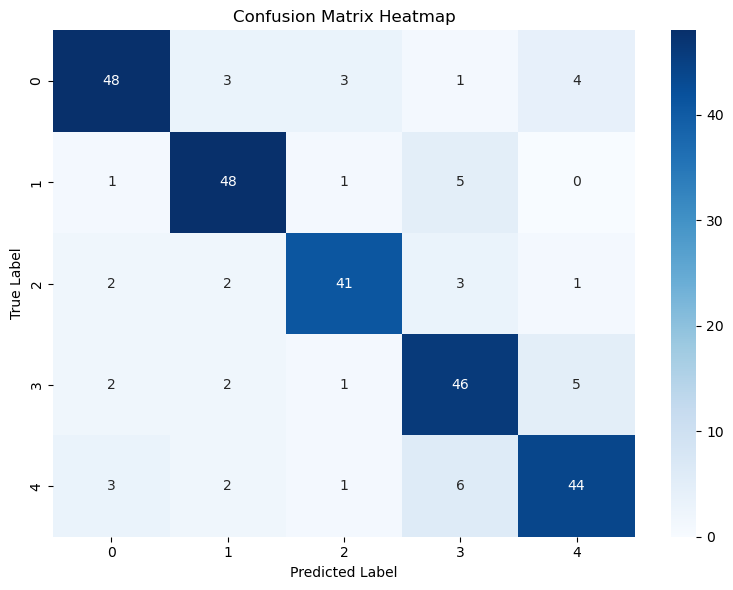

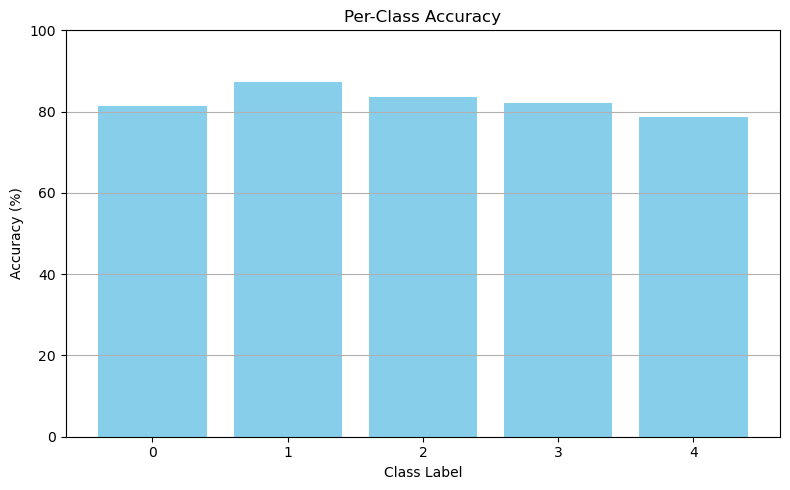

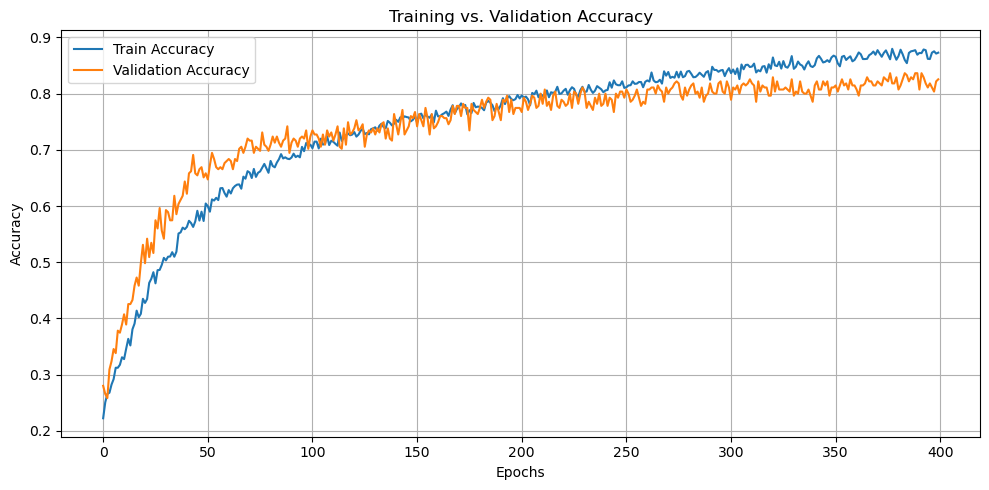

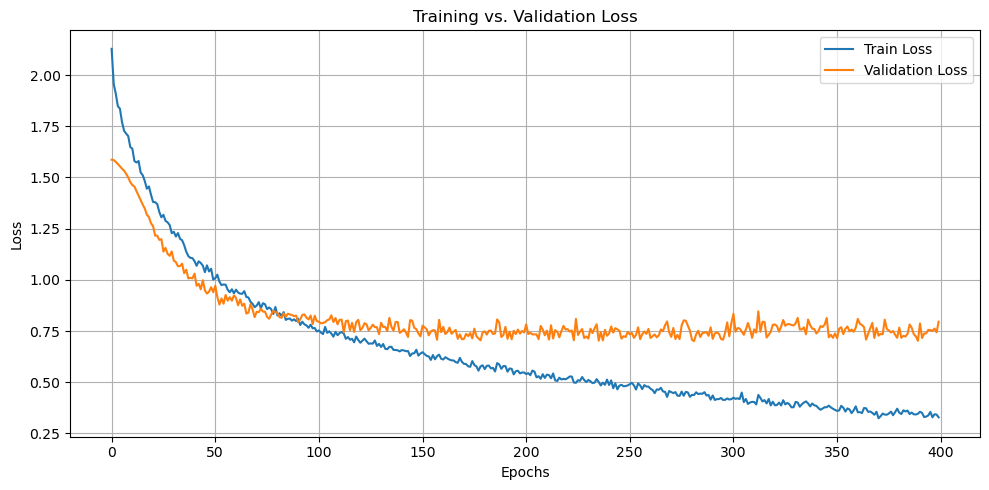

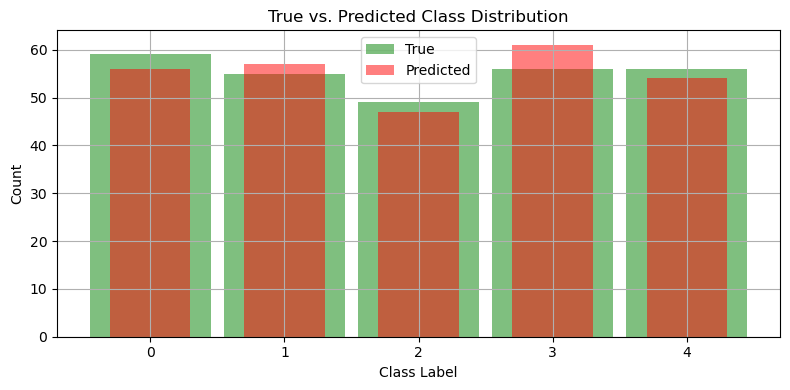

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create a folder for plots
plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)

# === Confusion Matrix Heatmap ===
def plot_confusion_matrix_heatmap(conf_mat):
    plt.figure(figsize=(8, 6))
    labels = [0, 1, 2, 3, 4]
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "confusion_matrix_heatmap.png"))
    plt.show()

# === Per-Class Accuracy Bar Chart ===
def plot_per_class_accuracy(conf_mat):
    labels = [0, 1, 2, 3, 4]
    per_class_acc = [100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0 for i in labels]
    
    plt.figure(figsize=(8, 5))
    plt.bar(labels, per_class_acc, color="skyblue")
    plt.ylim(0, 100)
    plt.xlabel("Class Label")
    plt.ylabel("Accuracy (%)")
    plt.title("Per-Class Accuracy")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "per_class_accuracy.png"))
    plt.show()

# === Training vs Validation Accuracy ===
def plot_training_validation_accuracy(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs. Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_accuracy.png"))
    plt.show()

# === Training vs Validation Loss ===
def plot_training_validation_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_loss.png"))
    plt.show()

# === Prediction vs True Class Distribution ===
def plot_prediction_distribution(y_test, y_pred):
    labels = [0, 1, 2, 3, 4]
    plt.figure(figsize=(8, 4))
    plt.hist(y_test, bins=np.arange(6)-0.5, alpha=0.5, label="True", color='g', rwidth=0.9)
    plt.hist(y_pred, bins=np.arange(6)-0.5, alpha=0.5, label="Predicted", color='r', rwidth=0.6)
    plt.xticks(labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title("True vs. Predicted Class Distribution")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "true_vs_predicted_distribution.png"))
    plt.show()

# === Run and Save All Plots ===
plot_confusion_matrix_heatmap(conf_mat)
plot_per_class_accuracy(conf_mat)
plot_training_validation_accuracy(history)
plot_training_validation_loss(history)
plot_prediction_distribution(y_test, y_pred)


In [1]:
!pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached sklearn_compat-0.1.3-py3-none-any.whl.metadata (18 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
Using cached sklearn_compat-0.1.3-py3-none-any.whl (18 kB)
